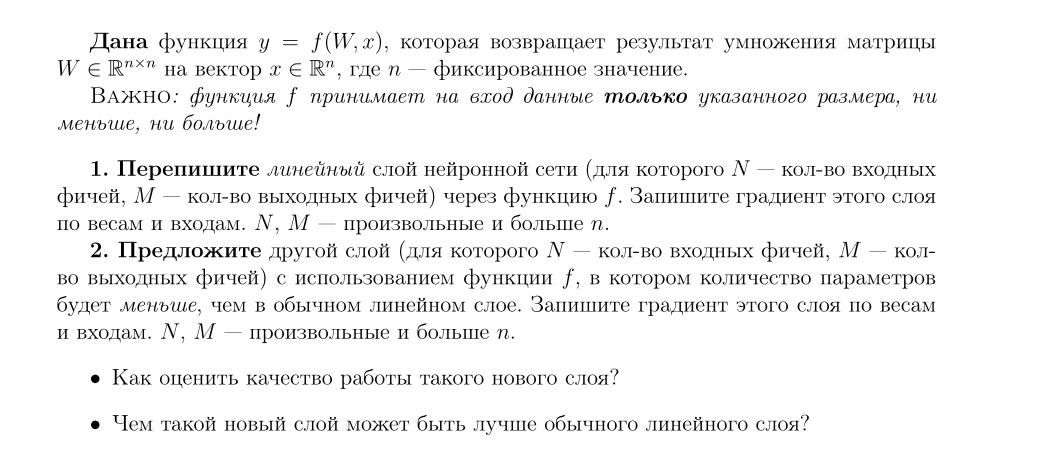

In [ ]:
n = 32
N = 78
M = 145

## Задание 1

In [ ]:
import numpy as np

In [ ]:
def f(W: np.ndarray, x: np.ndarray) -> np.ndarray:
    if np.shape(W) != (n, n):
        print(f"Wrong input: {W.shape}")
        return False
    return np.matmul(W, x)

In [ ]:
# Входные параметры
layer_input = np.random.random_sample(size=(N, 1))

# Оригинальный линейный слой
linear_layer = np.random.random_sample(size=(M, N))

In [ ]:
np.matmul(linear_layer, layer_input)

In [ ]:
def resize_matrix(matrix: np.ndarray):
    zeroes_for_dim_0 = (n - (matrix.shape[0] % n)) % n
    zeroes_for_dim_1 = (n - (matrix.shape[1] % n)) % n
    
    matrix_sized = np.concat((matrix, np.zeros(shape=(zeroes_for_dim_0, matrix.shape[1]))))
    matrix_sized = np.concat((matrix_sized, np.zeros(shape=(matrix.shape[0] + zeroes_for_dim_0, zeroes_for_dim_1))), axis=1)
    
    return matrix_sized

def resize_vector(vector: np.ndarray):
    zeroes_to_add = (n - (vector.shape[1] % n)) % n
    
    vector_sized = np.concat((vector, np.zeros(shape=(zeroes_to_add, 1))))
    return vector_sized

linear_layer_sized, linear_input_sized = resize_matrix(linear_layer), resize_vector(layer_input)

In [ ]:
print(n)
print(f"Размер матрицы линейного слоя до нормализации: {linear_layer.shape}")
print(f"Размер матрицы линейного слоя после нормализации: {linear_layer_sized.shape}", end="\n\n")

print(f"Размер входных данных до нормализации: {layer_input.shape}")
print(f"Размер входных данных после нормализации: {linear_input_sized.shape}")

In [ ]:
# Функция принимает матрицу и вектор и вычисляет их перемножение с помощью функции f
def block_matmul(layer: np.ndarray, layer_input: np.ndarray):
    y_blocks = []
    
    for y in range(0, layer.shape[0] // n):
        y_i = np.zeros(n)
        
        for x in range(0, layer.shape[1] // n):
            A = layer[y * n:(y + 1) * n, x * n:(x + 1) * n]
            layer_partition = layer_input[x*n:(x+1)*n]
            y_i += f(A, layer_partition).flatten()
        y_blocks.append(y_i)
    return np.concat(y_blocks)


# Основная функция, предоставляющая решение для первого задания
def compute_layer(linear_layer: np.ndarray, x: np.ndarray):
    linear_layer_sized = resize_matrix(linear_layer)
    linear_input_sized = resize_vector(x)
    y = block_matmul(layer=linear_layer_sized, layer_input=linear_input_sized)
    
    # Поскольку мы добавляли нули в матрицу и входные данные, в y на конце могут содержаться лишние нули.
    return y[:N]

compute_layer(linear_layer, layer_input)

## Задание 2

In [ ]:
r = min(M, N) // 2
assert r > 0
print(f"Исходный слой: {N * M} параметров")
print(f"Новый слой: {N * r + M * r} параметров")

In [ ]:
layer_U = np.random.random_sample(size=(M, r))
layer_V = np.random.random_sample(size=(r, N))

def compute_small_layer(U: np.ndarray, V: np.ndarray, x: np.ndarray):
    U_siezed, V_siezed = resize_matrix(U), resize_matrix(V)
    x = resize_vector(x)
    
    h = block_matmul(V_siezed, x)
    y = block_matmul(U_siezed, h)
    
    return y[:N]

y = compute_small_layer(layer_U, layer_V, layer_input)